# Evaluating Agent Router and Skills Using EDD
---

## Evaluation-Driven Development (EDD) 

### Overview

This project is used to create and evalate `spans` related to Agent `traces`.


### Import libraries

In [6]:
from openai import OpenAI
import pandas as pd
import os
import json
import duckdb
import logging
import pydantic

from pydantic import BaseModel, Field
from IPython.display import Markdown
from typing import Any, Dict, List, Sequence, Union
from dotenv import load_dotenv

import phoenix as px
from phoenix.otel import register
from openinference.instrumentation.openai import OpenAIInstrumentor
from openinference.semconv.trace import SpanAttributes
from opentelemetry.trace import Status, StatusCode
from openinference.instrumentation import TracerProvider

from tqdm import tqdm
from phoenix.evals import (
    TOOL_CALLING_PROMPT_TEMPLATE, 
    llm_classify,
    OpenAIModel
)
from phoenix.trace import SpanEvaluations
from phoenix.trace.dsl import SpanQuery
#from phoenix.client.types.spans import SpanQuery
from openinference.instrumentation import suppress_tracing

import nest_asyncio
nest_asyncio.apply()



### Initialize OpenAI Client|

In [7]:
load_dotenv() 
AI_API_KEY = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key=AI_API_KEY)

MODEL = "gpt-4o"

###

### Setup Phoenix

**Setup Environment and OpenTelemetry**

In [8]:
PROJECT_NAME = "evaluating_agent_router_and_skills"
PHOENIX_COLLECTOR_ENDPOINT="http://localhost:6006/v1/traces"

In [9]:
tracer_provider = register(
    project_name=PROJECT_NAME,
    endpoint=PHOENIX_COLLECTOR_ENDPOINT,
    auto_instrument=True
)


DependencyConflict: requested: "openai >= 1.69.0" but found: "openai 1.66.3"


OpenTelemetry Tracing Details
|  Phoenix Project: evaluating_agent_router_and_skills
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: http://localhost:6006/v1/traces
|  Transport: HTTP + protobuf
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



**Setup OpenAI Instrumentation**

`OpenAIInsrumentor` is used to automatically collect OpenAI LLM calls from code.

In [10]:
OpenAIInstrumentor().instrument(tracer_provider = tracer_provider)

DependencyConflict: requested: "openai >= 1.69.0" but found: "openai 1.66.3"


**Get Tracer Object**

the tracer object creats spans from the tracer provider. The tracer object is used to create the LLM calls, tooling, and agent spans. 

In [11]:
tracer = tracer_provider.get_tracer(__name__)

## Tracing Agent 

We will now collect traces from agent:

1. For LLM calls, OpenAIInstrumentor automatically collects **spans** of the type LLM, which containls input and output of an LLM call. 
2. For any other step, manuyal instrumentation will be used to create the sequence of spans in the trace. 


For this agent will will create the following span types:

* **chain** - represents the starting point of a sequence of spans, or a link between spans.
* **tool** - represents the call to an external tool. 
* **agent** - represents the main span that encompases the entire trace -- the main span capturing all calls to LLMs and Tools. 

In [12]:
# define the path to the transactional data
TRANSACTION_DATA_FILE_PATH = 'data/Store_Sales_Price_Elasticity_Promotions_Data.parquet'

**Prompt Template**

In [13]:
SQL_GENERATION_PROMPT = """
Generate an SQL query based on the prompt that follows. Do not reply with anything besides the SQL query.
The prompt is: {prompt}

The available columns are: {columns}
The table name is: {table_name}
"""

**Helper Functions**

In [14]:
def generate_sql_query(prompt: str, columns: list[str], table_name: str) -> str:
    """
    Generate a valid SQL query from a natural language prompt.

    Parameters
    ----------
    prompt : str
        Natural language query.
    columns : list[str]
        Column names in the target table.
    table_name : str
        Name of the table to query.

    Returns
    -------
    str
        Generated SQL query string.
    """
    formatted_prompt = SQL_GENERATION_PROMPT.format(
        prompt=prompt,
        columns=columns,
        table_name=table_name
    )

    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": formatted_prompt}],
    )

    return response.choices[0].message.content.strip()


In [15]:
@tracer.tool()
def lookup_sales_data(prompt: str) -> str:
    """
    Query sales data from a Parquet file using LLM-generated SQL.

    Parameters
    ----------
    prompt : str
        Natural language query.

    Returns
    -------
    str
        Query result as formatted text or an error message.
    """
    try:
        table_name = "sales"

        # Step 1: Load Parquet into DuckDB
        df = pd.read_parquet(TRANSACTION_DATA_FILE_PATH)
        duckdb.sql(f"CREATE TABLE IF NOT EXISTS {table_name} AS SELECT * FROM df")

        # Step 2: Generate SQL and clean output
        sql_query = generate_sql_query(prompt, df.columns.tolist(), table_name)
        sql_query = sql_query.strip().replace("```sql", "").replace("```", "")

        # Step 3: Execute SQL and return results
        result = duckdb.sql(sql_query).df()
        return result.to_string()

    except Exception as e:
        return f"Error accessing data: {e}"


### Data Analysis Tool

In [16]:
DATA_ANALYSIS_PROMPT = """
Analyze the following data: {data}
Your job is to answer the following question: {prompt}
"""

In [17]:
@tracer.tool()
def analyze_sales_data(prompt: str, data: str) -> str:
    """
    Generate an AI-based sales data analysis.

    Formats a prompt using the provided template, data, and instruction,
    then queries a chat-based LLM for an analytical response.

    Args:
        prompt (str): Instruction describing the analysis task.
        data (str): Sales dataset or text input to analyze.

    Returns:
        str: LLM-generated analysis, or a fallback message if empty.
    """
    formatted_prompt = DATA_ANALYSIS_PROMPT.format(data=data, prompt=prompt)

    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": formatted_prompt}],
    )

    analysis = response.choices[0].message.content
    return analysis if analysis else "No analysis could be generated"

### Data Visualization Tool

**Step 1:** Create chart configuration: chart type, title, data, labels for x-axis and y-axis (Using an LLM call)

In [18]:
CHART_CONFIGURATION_PROMPT = """
Generate a chart configuration based on this data: {data}
The goal is to show: {visualization_goal}
"""

In [19]:
class VisualizationConfig(BaseModel):
    """
    Configuration schema for chart generation.

    Defines parameters for creating visualizations,
    including chart type, axes, and title.
    """
    chart_type: str = Field(..., description="Type of chart to generate (e.g., bar, line, scatter).")
    x_axis: str = Field(..., description="Column name for the x-axis.")
    y_axis: str = Field(..., description="Column name for the y-axis.")
    title: str = Field(..., description="Chart title.")

In [20]:
@tracer.chain()
def extract_chart_config(data: str, visualization_goal: str) -> dict:
    """Generate chart visualization configuration
    
    Args:
        data: String containing the data to visualize
        visualization_goal: Description of what the visualization should show
        
    Returns:
        Dictionary containing line chart configuration
    """
    formatted_prompt = CHART_CONFIGURATION_PROMPT.format(data=data,
                                                  visualization_goal=visualization_goal)
    
    response = client.beta.chat.completions.parse(
        model=MODEL,
        messages=[{"role": "user", "content": formatted_prompt}],
        response_format=VisualizationConfig,
    )
    
    try:
        # Extract axis and title info from response
        content = response.choices[0].message.content
        
        # Return structured chart config
        return {
            "chart_type": content.chart_type,
            "x_axis": content.x_axis,
            "y_axis": content.y_axis,
            "title": content.title,
            "data": data
        }
    except Exception:
        return {
            "chart_type": "bar", 
            "x_axis": "date",
            "y_axis": "value",
            "title": visualization_goal,
            "data": data
        }

**Step 2:** Generate Python code based on configuration generated on step 1 (Using an LLM call)

In [21]:
CREATE_CHART_PROMPT = """
    Write python code to create a chart based on the configuration that follows.
    Only return the code, for the month of Novemeber, no other text.
    config: {config}
"""

In [22]:
@tracer.chain()
def create_chart(config: dict) -> str:
    """
    Generate Python code for a chart based on the given configuration.

    Args:
        config (dict): Chart parameters including type, axes, and title.

    Returns:
        str: Python code string for rendering the chart.
    """
    formatted_prompt = CREATE_CHART_PROMPT.format(config=config)

    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "user", "content": formatted_prompt}],
    )

    code = response.choices[0].message.content
    code = code.replace("```python", "").replace("```", "")
    code = code.strip()

    return code


In [23]:
@tracer.chain()
def generate_visualization(data: str, visualization_goal: str) -> str:
    """
    Generate Python code for a visualization based on input data and goal.

    Args:
        data (str): Dataset or structured text to visualize.
        visualization_goal (str): Description of the intended visualization.

    Returns:
        str: Python code that creates the requested visualization.
    """
    config = extract_chart_config(data, visualization_goal)
    code = create_chart(config)
    return code

## Defining the Router

### Router Schema    

Now that all skills (tools) have been defined, we move to creating the router. The router will take the original user input and act as the planner. The router will also be responsible for calling tools. After each tool call is completed, the router will evaluate if additional tools should be called. 

In [24]:
# Define tools/functions that can be called by the model
tools = [
    {
        "type": "function",
        "function": {
            "name": "lookup_sales_data",
            "description": "Look up data from Store Sales Price Elasticity Promotions dataset",
            "parameters": {
                "type": "object",
                "properties": {
                    "prompt": {"type": "string", "description": "The unchanged prompt that the user provided."}
                },
                "required": ["prompt"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "analyze_sales_data", 
            "description": "Analyze sales data to extract insights",
            "parameters": {
                "type": "object",
                "properties": {
                    "data": {"type": "string", "description": "The lookup_sales_data tool's output."},
                    "prompt": {"type": "string", "description": "The unchanged prompt that the user provided."}
                },
                "required": ["data", "prompt"]
            }
        }
    },
    {
        "type": "function",
        "function": {
            "name": "generate_visualization",
            "description": "Generate Python code to create data visualizations",
            "parameters": {
                "type": "object", 
                "properties": {
                    "data": {"type": "string", "description": "The lookup_sales_data tool's output."},
                    "visualization_goal": {"type": "string", "description": "The goal of the visualization."}
                },
                "required": ["data", "visualization_goal"]
            }
        }
    }
]

# Dictionary mapping function names to their implementations
tool_implementations = {
    "lookup_sales_data": lookup_sales_data,
    "analyze_sales_data": analyze_sales_data, 
    "generate_visualization": generate_visualization
}

### Router Logic

The router is composed of a tool calling method and a main loop that runs until the router has completed a trace. 

In [25]:
SYSTEM_PROMPT = """
You are a helpful assistant that can answer questions about the Store Sales Price Elasticity Promotions dataset.
"""

In [26]:
# code for executing the tools returned in the model's response
@tracer.chain()
def handle_tool_calls(tool_calls, messages):
    
    for tool_call in tool_calls:   
        function = tool_implementations[tool_call.function.name]
        function_args = json.loads(tool_call.function.arguments)
        result = function(**function_args)
        messages.append({"role": "tool", 
                         "content": result, 
                         "tool_call_id": tool_call.id})
        
    return messages

In [27]:
def run_agent(messages, system_prompt: str = SYSTEM_PROMPT):
    print("Running agent with messages:", messages)

    if isinstance(messages, str):
        messages = [{"role": "user", "content": messages}]
        
    # Ensure system prompt is present and first
    if not any(
        isinstance(message, dict) and message.get("role") == "system"
        for message in messages
    ):
        sys_prompt = {"role": "system", "content": system_prompt}
        messages.insert(0, sys_prompt)  # put system prompt at the front

    while True:
        print("Making router call to OpenAI")
        response = client.chat.completions.create(
            model=MODEL,
            messages=messages,
            tools=tools,
        )
        messages.append(response.choices[0].message)
        tool_calls = response.choices[0].message.tool_calls
        print("Received response with tool calls:", bool(tool_calls))

        if tool_calls:
            print("Processing tool calls")
            messages = handle_tool_calls(tool_calls, messages)
        else:
            print("No tool calls, returning final response")
            return response.choices[0].message.content


### Main span

In [28]:
def start_main_span(messages):
    print("Starting main span with messages:", messages)
    
    with tracer.start_as_current_span(
        "AgentRun", openinference_span_kind="agent"
    ) as span:
        span.set_input(value=messages)
        ret = run_agent(messages) 
        print("Main span completed with return value:", ret)
        span.set_output(value=ret)
        span.set_status(StatusCode.OK)
        return ret


### Evals on multiple questions

In [29]:
agent_questions = [
    "What was the most popular product SKU?",
    "What was the total revenue across all stores?",
    "Which store had the highest sales volume?",
    "Create a bar chart showing total sales by store",
    "What percentage of items were sold on promotion?",
    "What was the average transaction value?"
]

for question in tqdm(agent_questions, desc="Processing questions"):
    try:
        ret = start_main_span([{"role": "user", "content": question}])
    except Exception as e:
        print(f"Error processing question: {question}")
        print(e)
        continue

Processing questions:   0%|          | 0/6 [00:00<?, ?it/s]

Starting main span with messages: [{'role': 'user', 'content': 'What was the most popular product SKU?'}]
Running agent with messages: [{'role': 'user', 'content': 'What was the most popular product SKU?'}]
Making router call to OpenAI
Received response with tool calls: True
Processing tool calls


Exception while exporting Span.
Traceback (most recent call last):
  File "c:\Users\ehcas\AI\Projects\StructuredLLMOutputs\.structllmoutputvenv\Lib\site-packages\urllib3\connection.py", line 204, in _new_conn
    sock = connection.create_connection(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ehcas\AI\Projects\StructuredLLMOutputs\.structllmoutputvenv\Lib\site-packages\urllib3\util\connection.py", line 85, in create_connection
    raise err
  File "c:\Users\ehcas\AI\Projects\StructuredLLMOutputs\.structllmoutputvenv\Lib\site-packages\urllib3\util\connection.py", line 73, in create_connection
    sock.connect(sa)
ConnectionRefusedError: [WinError 10061] No connection could be made because the target machine actively refused it

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\Users\ehcas\AI\Projects\StructuredLLMOutputs\.structllmoutputvenv\Lib\site-packages\urllib3\connectionpool.py", line 787, in urlopen


Making router call to OpenAI
Received response with tool calls: False
No tool calls, returning final response
Main span completed with return value: The most popular product SKU is 6200700, with a total quantity sold of 52,262 units.


Exception while exporting Span.
Traceback (most recent call last):
  File "c:\Users\ehcas\AI\Projects\StructuredLLMOutputs\.structllmoutputvenv\Lib\site-packages\urllib3\connection.py", line 204, in _new_conn
    sock = connection.create_connection(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ehcas\AI\Projects\StructuredLLMOutputs\.structllmoutputvenv\Lib\site-packages\urllib3\util\connection.py", line 85, in create_connection
    raise err
  File "c:\Users\ehcas\AI\Projects\StructuredLLMOutputs\.structllmoutputvenv\Lib\site-packages\urllib3\util\connection.py", line 73, in create_connection
    sock.connect(sa)
ConnectionRefusedError: [WinError 10061] No connection could be made because the target machine actively refused it

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\Users\ehcas\AI\Projects\StructuredLLMOutputs\.structllmoutputvenv\Lib\site-packages\urllib3\connectionpool.py", line 787, in urlopen


...

Exception while exporting Span.
Traceback (most recent call last):
  File "c:\Users\ehcas\AI\Projects\StructuredLLMOutputs\.structllmoutputvenv\Lib\site-packages\urllib3\connection.py", line 204, in _new_conn
    sock = connection.create_connection(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ehcas\AI\Projects\StructuredLLMOutputs\.structllmoutputvenv\Lib\site-packages\urllib3\util\connection.py", line 85, in create_connection
    raise err
  File "c:\Users\ehcas\AI\Projects\StructuredLLMOutputs\.structllmoutputvenv\Lib\site-packages\urllib3\util\connection.py", line 73, in create_connection
    sock.connect(sa)
ConnectionRefusedError: [WinError 10061] No connection could be made because the target machine actively refused it

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\Users\ehcas\AI\Projects\StructuredLLMOutputs\.structllmoutputvenv\Lib\site-packages\urllib3\connectionpool.py", line 787, in urlopen


Starting main span with messages: [{'role': 'user', 'content': 'What was the average transaction value?'}]
Running agent with messages: [{'role': 'user', 'content': 'What was the average transaction value?'}]
Making router call to OpenAI
Received response with tool calls: True
Processing tool calls


Exception while exporting Span.
Traceback (most recent call last):
  File "c:\Users\ehcas\AI\Projects\StructuredLLMOutputs\.structllmoutputvenv\Lib\site-packages\urllib3\connection.py", line 204, in _new_conn
    sock = connection.create_connection(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ehcas\AI\Projects\StructuredLLMOutputs\.structllmoutputvenv\Lib\site-packages\urllib3\util\connection.py", line 85, in create_connection
    raise err
  File "c:\Users\ehcas\AI\Projects\StructuredLLMOutputs\.structllmoutputvenv\Lib\site-packages\urllib3\util\connection.py", line 73, in create_connection
    sock.connect(sa)
ConnectionRefusedError: [WinError 10061] No connection could be made because the target machine actively refused it

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\Users\ehcas\AI\Projects\StructuredLLMOutputs\.structllmoutputvenv\Lib\site-packages\urllib3\connectionpool.py", line 787, in urlopen


Making router call to OpenAI
Received response with tool calls: False
No tool calls, returning final response
Main span completed with return value: The average transaction value is approximately $19.02.


Exception while exporting Span.
Traceback (most recent call last):
  File "c:\Users\ehcas\AI\Projects\StructuredLLMOutputs\.structllmoutputvenv\Lib\site-packages\urllib3\connection.py", line 204, in _new_conn
    sock = connection.create_connection(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ehcas\AI\Projects\StructuredLLMOutputs\.structllmoutputvenv\Lib\site-packages\urllib3\util\connection.py", line 85, in create_connection
    raise err
  File "c:\Users\ehcas\AI\Projects\StructuredLLMOutputs\.structllmoutputvenv\Lib\site-packages\urllib3\util\connection.py", line 73, in create_connection
    sock.connect(sa)
ConnectionRefusedError: [WinError 10061] No connection could be made because the target machine actively refused it

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "c:\Users\ehcas\AI\Projects\StructuredLLMOutputs\.structllmoutputvenv\Lib\site-packages\urllib3\connectionpool.py", line 787, in urlopen


In [ ]:
print(TOOL_CALLING_PROMPT_TEMPLATE)


You are an evaluation assistant evaluating questions and tool calls to
determine whether the tool called would answer the question. The tool
calls have been generated by a separate agent, and chosen from the list of
tools provided below. It is your job to decide whether that agent chose
the right tool to call.

    [BEGIN DATA]
    ************
    [Question]: {question}
    ************
    [Tool Called]: {tool_call}
    [END DATA]

Your response must be single word, either "correct" or "incorrect",
and should not contain any text or characters aside from that word.
"incorrect" means that the chosen tool would not answer the question,
the tool includes information that is not presented in the question,
or that the tool signature includes parameter values that don't match
the formats specified in the tool signatures below.

"correct" means the correct tool call was chosen, the correct parameters
were extracted from the question, the tool call generated is runnable and correct,
and tha

: 

: 

: 

: 

: 

#### Router Evals Using LLM-as-a-Judge

**Querying the Required Spans**

In [ ]:
query = SpanQuery().where(
    # Filter for the `LLM` span kind.
    # The filter condition is a string of valid Python boolean expression.
    "span_kind == 'LLM'",
).select(
    # extract columns and rename them
    question="input.value",
    tool_call="llm.tools"
)

# The Phoenix Client can take this query and return the dataframe.
tool_calls_df = px.Client().query_spans(
    query, 
    project_name=PROJECT_NAME, 
    timeout=None
    )

tool_calls_df = tool_calls_df.dropna(subset=["tool_call"])

tool_calls_df.head()

C:\Users\ehcas\AppData\Local\Temp\ipykernel_30056\880634416.py:12: DeprecationWarning: Migrate to using client.spans.get_spans_dataframe via arize-phoenix-client
  tool_calls_df = px.Client().query_spans(


,question,tool_call
context.span_id,,
3fab42f6ed4d3d01,"{""messages"": [{""role"": ""system"", ""content"": ""\...","[{'tool': {'json_schema': '{""type"": ""function""..."
15430e10737dcfdc,"{""messages"": [{""role"": ""system"", ""content"": ""\...","[{'tool': {'json_schema': '{""type"": ""function""..."
dbd05b940bed7585,"{""messages"": [{""role"": ""system"", ""content"": ""\...","[{'tool': {'json_schema': '{""type"": ""function""..."
62bf3f7a23a0b8ce,"{""messages"": [{""role"": ""system"", ""content"": ""\...","[{'tool': {'json_schema': '{""type"": ""function""..."
d7175b0e7ed47982,"{""messages"": [{""role"": ""system"", ""content"": ""\...","[{'tool': {'json_schema': '{""type"": ""function""..."


: 

: 

: 

: 

: 

**Evaluating Tool Calling**

In [ ]:
with suppress_tracing():
    tool_call_eval = llm_classify(
        data = tool_calls_df,
        template = TOOL_CALLING_PROMPT_TEMPLATE.template[0].template.replace(
            "{tool_definitions}", 
            json.dumps(tools).replace("{", '"').replace("}", '"')
            ),
        rails = ['correct', 'incorrect'],
        model=OpenAIModel(model="gpt-4o"),
        provide_explanation=True
    )

tool_call_eval['score'] = tool_call_eval.apply(lambda x: 1 if x['label']=='correct' else 0, axis=1)

tool_call_eval.head()

llm_classify |          | 0/13 (0.0%) | ⏳ 00:00<? | ?it/s

,label,explanation,exceptions,execution_status,execution_seconds,prompt_tokens,completion_tokens,total_tokens,score
context.span_id,,,,,,,,,
3fab42f6ed4d3d01,correct,The question asks for the average transaction ...,[],COMPLETED,3.016388,1196,77,1273,1
15430e10737dcfdc,correct,The question asks for the average transaction ...,[],COMPLETED,3.117553,1321,94,1415,1
dbd05b940bed7585,correct,The question asks for a percentage of items so...,[],COMPLETED,3.226091,1198,78,1276,1
62bf3f7a23a0b8ce,correct,The question asks for the percentage of items ...,[],COMPLETED,3.367822,1328,77,1405,1
d7175b0e7ed47982,incorrect,The question asks for a bar chart showing tota...,[],COMPLETED,5.606113,1199,75,1274,0


: 

: 

: 

: 

: 

In [ ]:
# write evals to Phoenix
from phoenix.client import Client

Client().spans.log_span_annotations_dataframe(
    dataframe=tool_call_eval,
    annotation_name="ToolCallingEval",
    annotator_kind="LLM",
    sync=True
)

[{'id': 'U3BhbkFubm90YXRpb246MQ=='},
 {'id': 'U3BhbkFubm90YXRpb246Mg=='},
 {'id': 'U3BhbkFubm90YXRpb246Mw=='},
 {'id': 'U3BhbkFubm90YXRpb246NA=='},
 {'id': 'U3BhbkFubm90YXRpb246NQ=='},
 {'id': 'U3BhbkFubm90YXRpb246Ng=='},
 {'id': 'U3BhbkFubm90YXRpb246Nw=='},
 {'id': 'U3BhbkFubm90YXRpb246OA=='},
 {'id': 'U3BhbkFubm90YXRpb246OQ=='},
 {'id': 'U3BhbkFubm90YXRpb246MTA='},
 {'id': 'U3BhbkFubm90YXRpb246MTE='},
 {'id': 'U3BhbkFubm90YXRpb246MTI='},
 {'id': 'U3BhbkFubm90YXRpb246MTM='}]

: 

: 

: 

: 

: 

**Evaluating Python Code**

Tool 3 - Data Visualization Evals

In [ ]:
query = SpanQuery().where(
    "name =='generate_visualization'"
).select(
    generated_code="output.value"
)

# The Phoenix Client can take this query and return the dataframe.
code_gen_df = px.Client().query_spans(query, 
                                      project_name=PROJECT_NAME, 
                                      timeout=None)

code_gen_df.head()

C:\Users\ehcas\AppData\Local\Temp\ipykernel_30056\867214596.py:8: DeprecationWarning: Migrate to using client.spans.get_spans_dataframe via arize-phoenix-client
  code_gen_df = px.Client().query_spans(query,


,generated_code
context.span_id,
64c6954b4b7a77bd,import matplotlib.pyplot as plt\nimport pandas...


: 

: 

: 

: 

: 

In [ ]:
def code_is_runnable(output: str) -> bool:
    """Check if the code is runnable"""
    output = output.strip()
    output = output.replace("```python", "").replace("```", "")
    try:
        exec(output)
        return True
    except Exception as e:
        return False

: 

: 

: 

: 

: 

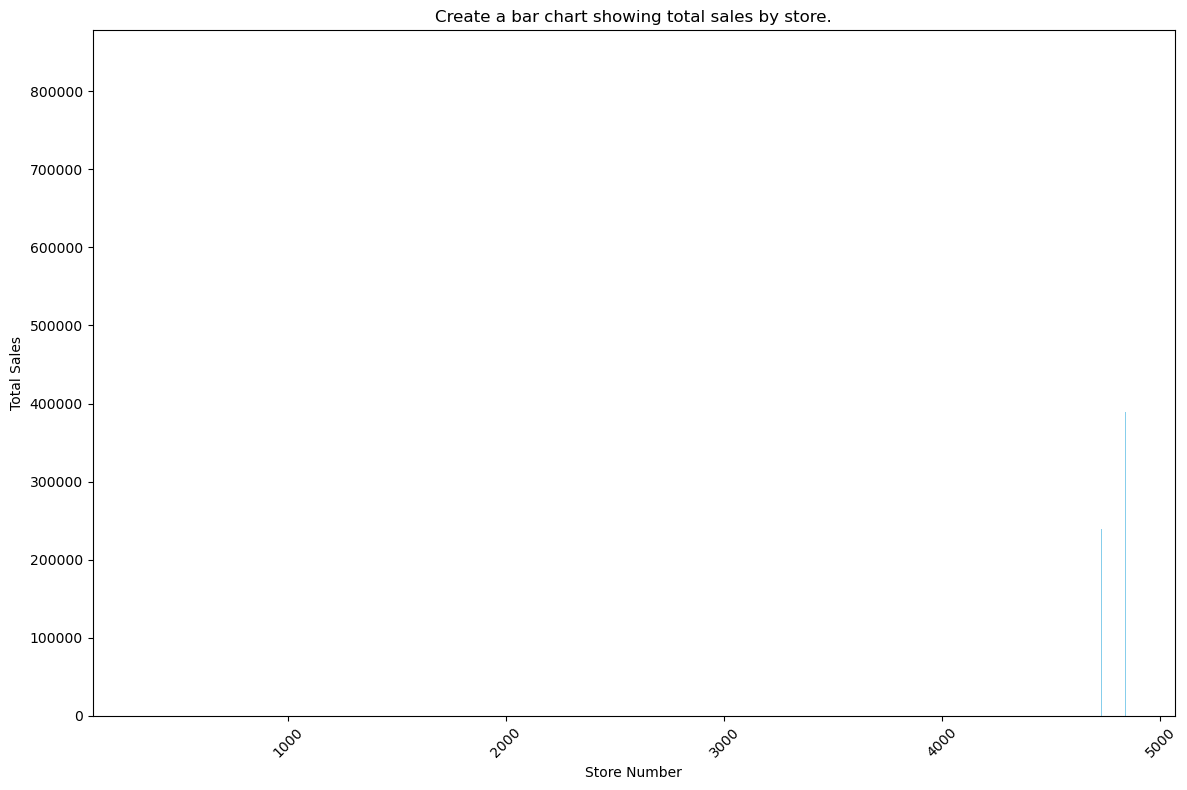

: 

: 

: 

: 

: 

In [ ]:
code_gen_df["label"] = code_gen_df["generated_code"].apply(code_is_runnable).map({True: "runnable", False: "not_runnable"})
code_gen_df["score"] = code_gen_df["label"].map({"runnable": 1, "not_runnable": 0})


In [ ]:
px.Client().log_evaluations(
    SpanEvaluations(eval_name="Runnable Code Eval", dataframe=code_gen_df),
)

: 

: 

: 

: 

: 

**Evaluating Clarity of Analysis**

In [ ]:
CLARITY_LLM_JUDGE_PROMPT = """
In this task, you will be presented with a query and an answer. Your objective is to evaluate the clarity 
of the answer in addressing the query. A clear response is one that is precise, coherent, and directly 
addresses the query without introducing unnecessary complexity or ambiguity. An unclear response is one 
that is vague, disorganized, or difficult to understand, even if it may be factually correct.

Your response should be a single word: either "clear" or "unclear," and it should not include any other 
text or characters. "clear" indicates that the answer is well-structured, easy to understand, and 
appropriately addresses the query. "unclear" indicates that some part of the response could be better 
structured or worded.
Please carefully consider the query and answer before determining your response.

After analyzing the query and the answer, you must write a detailed explanation of your reasoning to 
justify why you chose either "clear" or "unclear." Avoid stating the final label at the beginning of your 
explanation. Your reasoning should include specific points about how the answer does or does not meet the 
criteria for clarity.

[BEGIN DATA]
Query: {query}
Answer: {response}
[END DATA]
Please analyze the data carefully and provide an explanation followed by your response.

EXPLANATION: Provide your reasoning step by step, evaluating the clarity of the answer based on the query.
LABEL: "clear" or "unclear"
"""

: 

: 

: 

: 

: 

In [ ]:
query = SpanQuery().where(
    "span_kind=='AGENT'"
).select(
    response="output.value",
    query="input.value"
)

# The Phoenix Client can take this query and return the dataframe.
clarity_df = px.Client().query_spans(query, 
                                     project_name=PROJECT_NAME,
                                     timeout=None)

clarity_df.head()

: 

: 

: 

: 

: 

In [ ]:
with suppress_tracing():
    clarity_eval = llm_classify(
        dataframe = clarity_df,
        template = CLARITY_LLM_JUDGE_PROMPT,
        rails = ['clear', 'unclear'],
        model=OpenAIModel(model="gpt-4o"),
        provide_explanation=True
    )

clarity_eval['score'] = clarity_eval.apply(lambda x: 1 if x['label']=='clear' else 0, axis=1)

clarity_eval.head()

: 

: 

: 

: 

: 

In [ ]:
px.Client().log_evaluations(
    SpanEvaluations(eval_name="Response Clarity", dataframe=clarity_eval),
)

: 

: 

: 

: 

: 

**Evaluating SQL Code Generation**

In [ ]:
SQL_EVAL_GEN_PROMPT = """
SQL Evaluation Prompt:
-----------------------
You are tasked with determining if the SQL generated appropiately answers a given instruction
taking into account its generated query and response.

Data:
-----
- [Instruction]: {question}
  This section contains the specific task or problem that the sql query is intended to solve.

- [Reference Query]: {sql_gen}
  This is the sql query submitted for evaluation. Analyze it in the context of the provided
  instruction.

Evaluation:
-----------
Your response should be a single word: either "correct" or "incorrect".
You must assume that the db exists and that columns are appropiately named.
You must take into account the response as additional information to determine the correctness.

- "correct" indicates that the sql query correctly solves the instruction.
- "incorrect" indicates that the sql query correctly does not solve the instruction correctly.

Note: Your response should contain only the word "correct" or "incorrect" with no additional text
or characters.
"""

: 

: 

: 

: 

: 

In [ ]:
query = SpanQuery().where(
    "span_kind=='LLM'"
).select(
    sql_gen="output.value",
    question="input.value",
)

# The Phoenix Client can take this query and return the dataframe.
sql_df = px.Client().query_spans(query, 
                                 project_name=PROJECT_NAME,
                                 timeout=None)

sql_df.head()

: 

: 

: 

: 

: 

In [ ]:
#sql_df = sql_df[sql_df["question"].str.contains("Generate an SQL query based on a prompt that follows", na=False)]

sql_df.head()

: 

: 

: 

: 

: 

In [ ]:
with suppress_tracing():
    sql_gen_eval = llm_classify(
        dataframe = sql_df,
        template = SQL_EVAL_GEN_PROMPT,
        rails = ['correct', 'incorrect'],
        model=OpenAIModel(model="gpt-4o"),
        provide_explanation=True
    )

sql_gen_eval['score'] = sql_gen_eval.apply(lambda x: 1 if x['label']=='correct' else 0, axis=1)

sql_gen_eval.head()

: 

: 

: 

: 

: 

In [ ]:
px.Client().log_evaluations(
    SpanEvaluations(eval_name="SQL Gen Eval", dataframe=sql_gen_eval),
)

: 

: 

: 

: 

: 

## Improving the System
---

In [ ]:
IMP_SQL_GENERATION_PROMPT = """
    You are an expert SQL developer. Your task is to generate a syntactically valid SQL query 
    that answers the user’s request based on the provided table schema. 
    You must return **only** the SQL code, formatted cleanly with uppercase SQL keywords.

    Follow these steps internally before producing the final answer:
    1. Analyze the user’s intent.
    2. Identify which columns and filters are relevant.
    3. Construct a valid SQL SELECT statement that answers the query.

    Schema Information:
    - Table Name: {table_name}
    - Available Columns: {columns}

    User Request:
    "{prompt}"

    Guidelines:
    - Return only the SQL query (no explanations, comments, or markdown).
    - Use exact column names as provided — do not invent or rename any.
    - Prefer simple, interpretable SQL (avoid unnecessary nesting or joins).
    - If the user request is ambiguous or impossible, return:
      SELECT "ERROR: Ambiguous or Unsupported Query" AS message;
"""

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 

: 